In [244]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [245]:
df = pd.read_csv("train.csv")
df_test_base = pd.read_csv("test.csv")
df_submit = pd.read_csv("sample_submission.csv", header=None, names=["Date", "Up"]) # 提出用のデータフレームを作成。提出用のCSVファイルには、予測する日付と上下予測の値を格納する必要があるため、Date列とUp列を持つデータフレームを作成しています。


In [246]:
df
# 2004年1月1日から2012年1月18日までの株価データが含まれています。
# Up列は、翌日の株価が前日の終値よりも上昇したかを示す二値のターゲット変数で、1は上昇、0は下降を意味

,Date,Open,High,Low,Close,Up
0,2004-01-02,50.85,50.91,50.62,50.72,1
1,2004-01-05,50.75,50.84,50.61,50.79,1
2,2004-01-06,50.87,51.26,50.86,51.15,1
3,2004-01-07,51.45,51.54,51.29,51.51,0
4,2004-01-08,51.15,51.33,51.02,51.28,0
...,...,...,...,...,...,...
2021,2012-01-11,108.62,109.00,108.41,108.86,1
2022,2012-01-12,109.68,109.90,109.44,109.83,0
2023,2012-01-13,109.53,109.72,109.08,109.66,1
2024,2012-01-17,109.99,110.47,109.57,109.96,1


In [247]:
df_test_base
# テストデータは2012年1月19日から2019年1月31日までの株価データが含まれています。

,Date,Open,High,Low,Close
0,2012-01-19,110.79,110.82,109.96,110.39
1,2012-01-20,110.45,111.10,110.36,110.73
2,2012-01-23,110.95,111.10,109.65,110.36
3,2012-01-24,110.16,110.16,108.13,108.39
4,2012-01-25,106.25,107.11,105.97,106.89
...,...,...,...,...,...
1195,2019-12-17,185.52,186.40,184.62,184.68
1196,2019-12-18,183.86,184.01,182.38,183.10
1197,2019-12-19,183.83,185.17,183.66,185.08
1198,2019-12-20,186.29,186.64,184.81,185.19


In [248]:
df_submit

,Date,Up
0,2012-01-26,0
1,2012-02-09,0
2,2012-02-24,0
3,2012-03-09,0
4,2012-03-23,0
...,...,...
195,2019-10-25,0
196,2019-11-08,0
197,2019-11-22,0
198,2019-12-09,0


<Axes: >

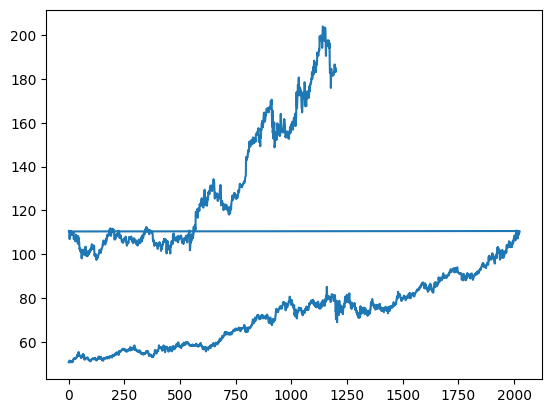

In [249]:
pd.concat([df["Close"], df_test_base["Close"]], axis=0).plot()
# 二つに分かれるのはindexが重複しているから。indexをリセットする必要がある。

<Axes: >

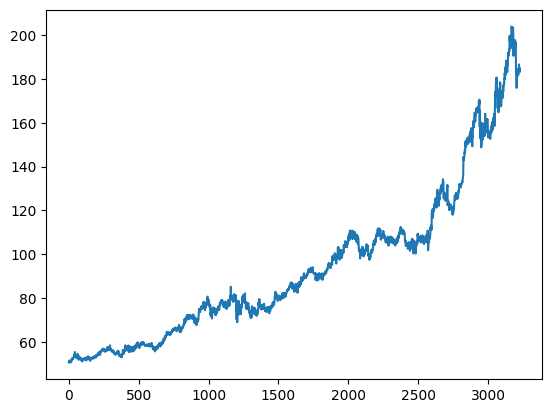

In [250]:
# indexをリセットしてからプロット
pd.concat([df["Close"], df_test_base["Close"]], axis=0).reset_index(drop=True).plot()

In [251]:
pd.concat([df["Close"], df_test_base["Close"]], axis=0).reset_index(drop=True)
# indexをリセットしてからプロットするために、reset_index(drop=True)を使用しています。これにより、元のindexが削除され、新しい連続したindexが作成されます。

0        50.72
1        50.79
2        51.15
3        51.51
4        51.28
         ...  
3221    184.68
3222    183.10
3223    185.08
3224    185.19
3225    183.34
Name: Close, Length: 3226, dtype: float64

<Axes: >

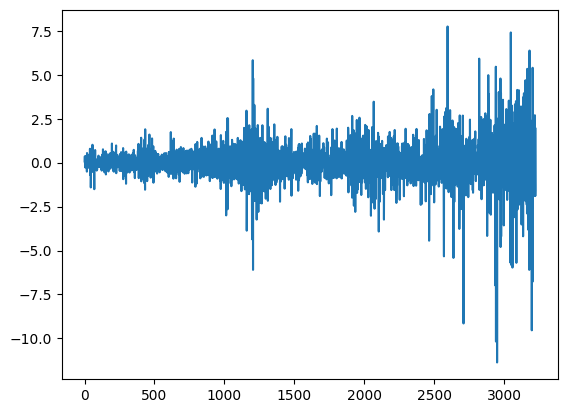

In [252]:
# 時系列データでは、差分を取ることで、データのトレンドや季節性を除去し、データの変動をより明確にすることができます。
# 差分を取ることで、株価の変動のパターンや傾向をより明確に把握できるようになります。
# 対数をとることもあり


pd.concat([df["Close"].diff(1), df_test_base["Close"].diff(1)], axis=0).reset_index(drop=True).plot()
# diff(1)は、1日前との差分を計算するためのメソッド


In [253]:
pd.concat([df, df["Close"].diff(1).rename("Close_diff"), df["Close"].diff(1).shift(1).rename("Close_diff_1daylag"), df["Close"].diff(1).shift(2).rename("Close_diff_2daylag"), df["Close"].diff(1).shift(3).rename("Close_diff_3daylag"), df["Close"].diff(1).shift(4).rename("Close_diff_4daylag"), df["Close"].diff(1).shift(5).rename("Close_diff_5daylag")], axis=1)

,Date,Open,High,Low,Close,Up,Close_diff,Close_diff_1daylag,Close_diff_2daylag,Close_diff_3daylag,Close_diff_4daylag,Close_diff_5daylag
0,2004-01-02,50.85,50.91,50.62,50.72,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-01-05,50.75,50.84,50.61,50.79,1,0.07,NaN,NaN,NaN,NaN,NaN
2,2004-01-06,50.87,51.26,50.86,51.15,1,0.36,0.07,NaN,NaN,NaN,NaN
3,2004-01-07,51.45,51.54,51.29,51.51,0,0.36,0.36,0.07,NaN,NaN,NaN
4,2004-01-08,51.15,51.33,51.02,51.28,0,-0.23,0.36,0.36,0.07,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2021,2012-01-11,108.62,109.00,108.41,108.86,1,-0.26,-0.43,-0.31,0.60,2.07,-1.21
2022,2012-01-12,109.68,109.90,109.44,109.83,0,0.97,-0.26,-0.43,-0.31,0.60,2.07
2023,2012-01-13,109.53,109.72,109.08,109.66,1,-0.17,0.97,-0.26,-0.43,-0.31,0.60
2024,2012-01-17,109.99,110.47,109.57,109.96,1,0.30,-0.17,0.97,-0.26,-0.43,-0.31


In [254]:

def data_pre(df, col):
  df = pd.concat([df, df[col].diff(1).rename(f"{col}_diff"), df[col].diff(1).shift(1).rename(f"{col}_diff_1daylag"), df[col].diff(1).shift(2).rename(f"{col}_diff_2daylag"), df[col].diff(1).shift(3).rename(f"{col}_diff_3daylag"), df[col].diff(1).shift(4).rename(f"{col}_diff_4daylag"), df[col].diff(1).shift(5).rename(f"{col}_diff_5daylag")], axis=1)
  df = df.drop(col, axis=1)

  return df

# 前日との差分を、Closeだけでなく、OpenやHigh、Lowなどの他の株価指標についても計算し、列として追加する。今から同じことを繰り返すので、関数にしておきます。

# df[col]
# 指定した列（例: Close）を取り出します。

# .diff(1)
# 1期前との差分を計算します。
# 例: 当日値 - 前日値。

# .shift(n)
# n 行ぶん下にずらします（ラグ特徴量）。
# shift(1) は1日前、shift(5) は5日前の差分を表します。

# .rename(f"...")
# 作った Series に列名を付けます。
# f"{col}_diff_3daylag" の f"..." は f文字列で、col="Close" なら Close_diff_3daylag になります。文字列も関数に組み込める。

# pd.concat([...], axis=1)
# axis=1 なので横方向（列方向）に連結します。
# 元の df に、差分列とラグ列をまとめて追加している、という意味です。

# 次の行 df = df.drop(col, axis=1)
# 元の生列（例: Close）は削除して、差分系の特徴量だけ残しています。

# 要するにこの関数は、「指定列を差分化し、1〜5日ラグの特徴量を作って、元列を消して返す」関数です。

In [255]:
# # これでもいいかも
# # 前日の"Close"との差分"Close_diff"列を追加し、これを1日shiftでずらした"Close_diff_1daylag"列を続けて追加する。これを5日まで繰り返す。
# # 元の生列（例: Close）は削除（して、差分系の特徴量だけ残す。）
# # 同じく、OpenやHigh、Lowなどの他の株価指標についても、これと同様に差分を取り列を追加する。
# # できたデータフレームを確認する。

# price_cols = ["Close", "Open", "High", "Low"]

# for col in price_cols:
#     diff_col = f"{col}_diff"
#     df[diff_col] = df[col].diff(1)

#     for lag in range(1, 6):
#         df[f"{col}_diff_{lag}daylag"] = df[diff_col].shift(lag)

# # 元の生列（Close/Open/High/Low）を削除して、差分系特徴量のみ残す
# df = df.drop(columns=price_cols)

# df.head(30)


In [256]:
df_tmp = data_pre(df, "Close")
df_tmp.head()
# colを"Close"にして上で作った関数を呼び出して、試しに確認してみる。

,Date,Open,High,Low,Up,Close_diff,Close_diff_1daylag,Close_diff_2daylag,Close_diff_3daylag,Close_diff_4daylag,Close_diff_5daylag
0,2004-01-02,50.85,50.91,50.62,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-01-05,50.75,50.84,50.61,1,0.07,NaN,NaN,NaN,NaN,NaN
2,2004-01-06,50.87,51.26,50.86,1,0.36,0.07,NaN,NaN,NaN,NaN
3,2004-01-07,51.45,51.54,51.29,0,0.36,0.36,0.07,NaN,NaN,NaN
4,2004-01-08,51.15,51.33,51.02,0,-0.23,0.36,0.36,0.07,NaN,NaN


In [257]:
# colを"Open"にして上で作った関数を呼び出して、これも試しに確認してみる。
df_tmp = data_pre(df_tmp, "Open")
df_tmp.head()

,Date,High,Low,Up,Close_diff,Close_diff_1daylag,Close_diff_2daylag,Close_diff_3daylag,Close_diff_4daylag,Close_diff_5daylag,Open_diff,Open_diff_1daylag,Open_diff_2daylag,Open_diff_3daylag,Open_diff_4daylag,Open_diff_5daylag
0,2004-01-02,50.91,50.62,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-01-05,50.84,50.61,1,0.07,NaN,NaN,NaN,NaN,NaN,-0.10,NaN,NaN,NaN,NaN,NaN
2,2004-01-06,51.26,50.86,1,0.36,0.07,NaN,NaN,NaN,NaN,0.12,-0.10,NaN,NaN,NaN,NaN
3,2004-01-07,51.54,51.29,0,0.36,0.36,0.07,NaN,NaN,NaN,0.58,0.12,-0.10,NaN,NaN,NaN
4,2004-01-08,51.33,51.02,0,-0.23,0.36,0.36,0.07,NaN,NaN,-0.30,0.58,0.12,-0.1,NaN,NaN


In [258]:
## 学習データへの特徴量追加
df = df.drop(["Date"], axis=1) # Date列は、株価予測のモデルにとっては意味のない特徴量なので、削除します。
df = data_pre(df, "Open") # Open列を差分化して、Open_diff列とOpen_diff_1daylag〜Open_diff_5daylag列を追加し、元のOpen列は削除します。
df = data_pre(df, "High") #
df = data_pre(df, "Low")
df = data_pre(df, "Close")

## テストデータへの特徴量追加
df_test = df_test_base.drop(["Date"], axis=1)
df_test = data_pre(df_test, "Open")
df_test = data_pre(df_test, "High")
df_test = data_pre(df_test, "Low")
df_test = data_pre(df_test, "Close")

In [259]:
## モデル構築

df_train, df_val = train_test_split(df, test_size=0.2)

col = "Up"
train_y = df_train[col]
train_x = df_train.drop(col, axis=1)

val_y = df_val[col]
val_x = df_val.drop(col, axis=1)

trains = lgb.Dataset(train_x, train_y)
valids = lgb.Dataset(val_x, val_y)

params = {
    "objective": "binary",
    "metric": "binary_logloss"
}

model = lgb.train(params, trains, valid_sets=valids, num_boost_round=1000, callbacks=[lgb.early_stopping(stopping_rounds=100)])

[LightGBM] [Info] Number of positive: 844, number of negative: 776
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.520988 -> initscore=0.084000
[LightGBM] [Info] Start training from score 0.084000
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[24]	valid_0's binary_logloss: 0.646675


In [260]:
# 予測
# Testデータと同じ構造になるように注意
predict = model.predict(df_test)
predict

array([0.88542536, 0.45755432, 0.49131416, ..., 0.61500775, 0.28032994,
       0.79445019])

In [261]:
# 確率値を0と1の二値に変換するための閾値を設定します。一般的には0.5がよく使われますが、データの特性や目的に応じて調整することもあります。
threshold = 0.5

predict_list = []
for i in predict:
  if i >= threshold:
    Up = 1 # 予測値が閾値以上の場合は1（株価が上昇する）と予測
  else: # 予測値が閾値未満の場合はUpを0（株価が下降する）と予測
    Up = 0
  predict_list.append(Up)

df_predict = pd.concat([df_test_base, pd.Series(predict_list).rename("Up")], axis=1)
# predict_listは、予測値を0と1の二値に変換したリストなのでpd.SeriesでDFに変換し、列名を"Up"にして、元のテストデータフレームdf_test_baseと横方向（列方向）に連結できる

In [262]:
df_submit = pd.merge(df_submit[["Date"]], df_predict[["Date", "Up"]], how="left", on="Date") 
# 提出用のデータフレームdf_submitと、予測結果を含むデータフレームdf_predictを、Date列をキーにして左結合（left join）することで、提出用のデータフレームに予測結果のUp列を追加しています。
# これにより、提出用のデータフレームには、各日付に対する株価の上昇予測が含まれることになります。

In [263]:
df_submit.to_csv("submit.csv", header=False, index=False)

In [ ]:
# いろんな特徴量を作ってみる
# また、いろんなモデルで得た結果をアンサンブルすることが必要